# Project 2: Clean and analyze messy shipment data with pandas

Run each cell with Shift+Enter, top to bottom. First run the upload cell and choose `shipments_raw.csv`. The guide explains what every step does.

In [1]:
# Upload shipments_raw.csv from your computer
from google.colab import files
uploaded = files.upload()

Saving shipments_raw.csv to shipments_raw.csv


## [1] Load

In [2]:
import pandas as pd
df = pd.read_csv("shipments_raw.csv")
print(df.shape)
df.head()

(1225, 11)


,shipment_id,order_date,ship_date,delivery_date,promised_days,carrier,mode,origin,destination,weight_kg,freight_cost_usd
0,SH10122,2026-05-21,2026-05-23,2026-05-31,8,harbor express,Truck,Pittsburgh,Chicago,685.5,1269.31
1,SH10484,08/19/2026,2026-08-21,2026-08-22,2,Summit Air Cargo,Air,Shanghai,Chicago,94.6,$690.57
2,SH10102,04/24/2026,04/24/2026,2026-05-18,24,Northstar Logistics,Ocean,Shanghai,New York City,1536.4,1322.29
3,SH10485,2026-07-13,2026-07-16,2026-07-21,5,ATLAS FREIGHT,Truck,Montreal,Chicago,563.5,"$1,222.96"
4,SH10592,2026-01-09,2026-01-11,2026-01-29,18,Atlas Freight,Ocean,Shanghai,Buffalo,1204.9,1139.19


## [2] Inspect

In [3]:
df.info()
print(df.isna().sum())
print("Duplicate rows:", df.duplicated().sum())
print(df["carrier"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1225 entries, 0 to 1224
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   shipment_id       1225 non-null   object 
 1   order_date        1225 non-null   object 
 2   ship_date         1225 non-null   object 
 3   delivery_date     1210 non-null   object 
 4   promised_days     1225 non-null   int64  
 5   carrier           1225 non-null   object 
 6   mode              1225 non-null   object 
 7   origin            1225 non-null   object 
 8   destination       1225 non-null   object 
 9   weight_kg         1185 non-null   float64
 10  freight_cost_usd  1225 non-null   object 
dtypes: float64(1), int64(1), object(9)
memory usage: 105.4+ KB
shipment_id          0
order_date           0
ship_date            0
delivery_date       15
promised_days        0
carrier              0
mode                 0
origin               0
destination          0
weight_kg  

## [3] Remove duplicates

In [4]:
before = len(df)
df = df.drop_duplicates()
print(f"Removed {before - len(df)} duplicate rows")

Removed 25 duplicate rows


## [4] Standardize carrier names

In [5]:
df["carrier"] = df["carrier"].str.strip().str.lower()
carrier_map = {
    "atlas freight": "Atlas Freight",
    "bluewave shipping": "BlueWave Shipping",
    "blue wave shipping": "BlueWave Shipping",
    "northstar logistics": "Northstar Logistics",
    "harbor express": "Harbor Express",
    "harbour express": "Harbor Express",
    "summit air cargo": "Summit Air Cargo",
}
df["carrier"] = df["carrier"].map(carrier_map)
print(df["carrier"].value_counts(dropna=False))

carrier
Harbor Express         264
Atlas Freight          249
BlueWave Shipping      246
Northstar Logistics    242
Summit Air Cargo       199
Name: count, dtype: int64


## [5] Fix cost column (text like "$1,234.50" -> number)

In [6]:
df["freight_cost_usd"] = (df["freight_cost_usd"].astype(str)
                          .str.replace("$", "", regex=False)
                          .str.replace(",", "", regex=False)
                          .astype(float))

## [6] Fix dates (two formats mixed together)

In [7]:
for col in ["order_date", "ship_date", "delivery_date"]:
    df[col] = pd.to_datetime(df[col], format="mixed")

## [7] Validation rules

In [8]:
bad_weight = df["weight_kg"] <= 0
bad_delivery = df["delivery_date"] < df["ship_date"]
print("Negative weights:", bad_weight.sum())
print("Delivered before shipped:", bad_delivery.sum())
df.loc[bad_weight, "weight_kg"] = None
df.loc[bad_delivery, "delivery_date"] = pd.NaT

# fill missing weights with the median weight for that shipping mode
df["weight_kg"] = df["weight_kg"].fillna(df.groupby("mode")["weight_kg"].transform("median"))
print(df.isna().sum())

Negative weights: 6
Delivered before shipped: 5
shipment_id          0
order_date           0
ship_date            0
delivery_date       20
promised_days        0
carrier              0
mode                 0
origin               0
destination          0
weight_kg            0
freight_cost_usd     0
dtype: int64


## [8] New columns

In [9]:
df["transit_days"] = (df["delivery_date"] - df["ship_date"]).dt.days
df["is_late"] = df["transit_days"] > df["promised_days"]
df["cost_per_kg"] = df["freight_cost_usd"] / df["weight_kg"]
df["month"] = df["order_date"].dt.to_period("M").astype(str)
delivered = df.dropna(subset=["delivery_date"])

## [9] Analysis

In [10]:
late_by_carrier = (delivered.groupby("carrier")["is_late"].mean()
                   .sort_values(ascending=False) * 100).round(1)
print("Late %, by carrier:\n", late_by_carrier)
print("Late %, by mode:\n", (delivered.groupby("mode")["is_late"].mean() * 100).round(1))
print("Late %, by month:\n", (delivered.groupby("month")["is_late"].mean() * 100).round(1))
print("Median cost per kg by mode:\n", df.groupby("mode")["cost_per_kg"].median().round(2))

Late %, by carrier:
 carrier
Northstar Logistics    32.5
Atlas Freight          14.8
Harbor Express         14.7
BlueWave Shipping      12.8
Summit Air Cargo       10.7
Name: is_late, dtype: float64
Late %, by mode:
 mode
Air      10.7
Ocean    20.4
Truck    16.7
Name: is_late, dtype: float64
Late %, by month:
 month
2026-01    12.5
2026-02    15.4
2026-03    14.7
2026-04    16.0
2026-05    12.3
2026-06    27.3
2026-07    23.7
2026-08    15.9
Name: is_late, dtype: float64
Median cost per kg by mode:
 mode
Air      8.44
Ocean    1.06
Truck    1.92
Name: cost_per_kg, dtype: float64


## [10] Chart

Text(0.5, 0, '% of shipments delivered late')

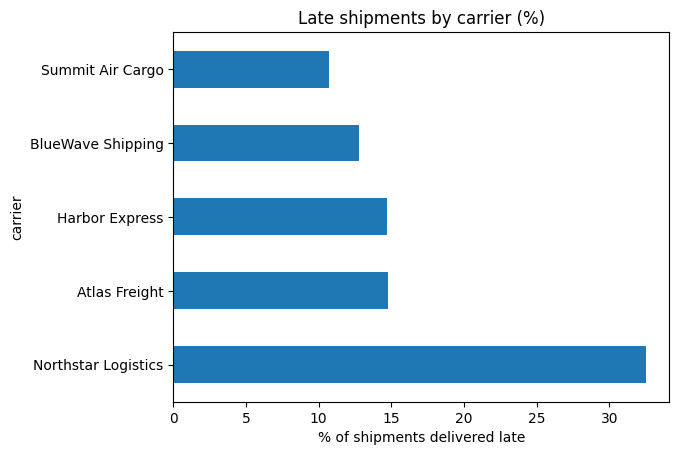

In [11]:
ax = late_by_carrier.plot(kind="barh", title="Late shipments by carrier (%)")
ax.set_xlabel("% of shipments delivered late")

## [11] Save

In [12]:
df.to_csv("shipments_clean.csv", index=False)
print("Saved", len(df), "rows")

Saved 1200 rows


## [12] STRETCH: predict late shipments

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model_df = delivered.copy()
model_df["order_month"] = model_df["order_date"].dt.month
X = pd.get_dummies(model_df[["carrier", "mode", "weight_kg", "order_month"]], columns=["carrier", "mode"])
y = model_df["is_late"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
model = LogisticRegression(max_iter=1000).fit(X_train, y_train)
print("Accuracy:", round(accuracy_score(y_test, model.predict(X_test)), 3))
print("Baseline (always guess 'on time'):", round(1 - y_test.mean(), 3))

Accuracy: 0.834
Baseline (always guess 'on time'): 0.837
